In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('transaksi_2025.csv', sep=";")
df.head()

,order_id,tanggal,nama_produk,kategori,kota,qty,harga,total,status,kasir,customer_id
0,TX-0001,2025-03-23,Teh Botol,Minuman,Jakarta,2,5000,10000,completed,Citra,C1094
1,TX-0002,2025-01-14,Sabun Mandi,Perawatan,Yogyakarta,5,12000,60000,completed,Andi,C1003
2,TX-0003,2025-01-12,Air Mineral,Minuman,Bandung,5,4000,20000,completed,Eko,C1025
3,TX-0004,2025-03-25,Shampoo,Perawatan,Yogyakarta,2,28000,56000,completed,Dewi,C1035
4,TX-0005,2025-01-01,Deterjen,Perawatan,Bandung,3,22000,66000,completed,Dewi,C1027


### Q7 Top 10 Customer

In [2]:
top_10_customer = df.groupby('customer_id').agg(
    Jumlah_Order=('customer_id', 'count'),
    Total_Belanja=('total', 'sum')
).reset_index()

top_10_sorted = top_10_customer.sort_values(by=['Total_Belanja', 'Jumlah_Order'], ascending=False).head(10)

display_table = top_10_sorted.copy()
display_table['Total_Belanja'] = display_table['Total_Belanja'].apply(lambda x: 'Rp {:,.0f}'.format(x))

display_table

,customer_id,Jumlah_Order,Total_Belanja
30,C1033,5,"Rp 737,000"
59,C1068,5,"Rp 596,000"
75,C1089,4,"Rp 521,000"
80,C1094,5,"Rp 419,000"
55,C1063,3,"Rp 391,000"
32,C1035,3,"Rp 375,000"
35,C1038,4,"Rp 275,000"
8,C1009,2,"Rp 275,000"
9,C1010,2,"Rp 250,000"
72,C1085,4,"Rp 244,000"


### Q8 Kategori Produk mana yang paling laris di tiap channel!

In [4]:
df_channel = pd.read_csv('FMCG_BT Data Analyst - Messy.csv', sep=';')
df_channel.head()

,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status,Unnamed: 15
0,01/01/2025,P00001,Minyak Goreng,Makanan,18000.0,1.0,NaN,0.15,20000.0,NaN,Shinta,Malang,Toko_Oren_Online,5.0,Returned,NaN
1,01/01/2025,P00002,Kopi,Makanan,25000.0,3.0,NaN,0.15,22000.0,NaN,Eli,Makassar,Offline,4.0,Failed,NaN
2,01/01/2025,P00003,Deterjen,PEMBERSIH,10000.0,3.0,NaN,0.15,25000.0,NaN,Eka,Medan,Offline,1.0,Pending,NaN
3,01/01/2025,P00004,Minyak Goreng,makanan,18000.0,1.0,NaN,0.15,20000.0,NaN,Zenia,Surabaya,Online - Toko Oren,3.0,Pending,NaN
4,01/01/2025,P00005,Pasta Gigi,Perawatan,15000.0,3.0,NaN,0.15,12000.0,NaN,Dicky,Bogor,Online - Toko Oren,1.0,Returned,NaN


### Cleaning Data

In [13]:
# 1. Menghapus spasi tambahan pada teks
df_channel['product_name'] = df_channel['product_name'].str.strip()
df_channel['category'] = df_channel['category'].str.strip().str.title()
df_channel['channel'] = df_channel['channel'].str.strip()

# 2. Menghapus data duplikat
df_channel = df_channel.drop_duplicates()

# 3. Menangani outlier pada quantity
df_channel = df_channel[df_channel['quantity'] > 0]

# 4. Standarisasi Channel
channel_map = {
    'Toko_Oren_Online': 'Online - Toko Oren',
    'hijau_toko_web': 'Online - Toko Hijau'
}
df_channel['channel'] = df_channel['channel'].replace(channel_map)

### Encoding

In [ ]:
# Rumus: (Price * Quantity) - Discount + Shipping_Fee 
df_channel['total_sales'] = (df_channel['price'] * df_channel['quantity']) - df_channel['discount'] + df_channel['shipping_fee']

# Mengisi kolom 'total' dengan nilai yang sama dengan total_sales
df_channel['total'] = df_channel['total_sales']

# Menghapus kolom yang tidak diperlukan
df_channel = df_channel.drop(columns=['Unnamed: 15'])

### Standarisasi

In [22]:
# Ubah baris ini untuk menangani format DD/MM/YYYY
df_channel['sales_date'] = pd.to_datetime(df_channel['sales_date'], format='mixed', dayfirst=True)

# Lanjutkan dengan proses pembersihan lainnya
df_channel['product_name'] = df_channel['product_name'].str.strip()
df_channel['category'] = df_channel['category'].str.strip().str.title()
df_channel['channel'] = df_channel['channel'].str.strip()

# Menghapus duplikat
df_channel = df_channel.drop_duplicates()

### Data Bersih

In [27]:
df_cleaning = df_channel
df_cleaning.head()

,sales_date,order_id,product_name,category,price,quantity,total,discount,shipping_fee,total_sales,customer_name,customer_address,channel,rating,status
0,2025-01-01,P00001,Minyak Goreng,Makanan,18000.0,1.0,37999.85,0.15,20000.0,37999.85,Shinta,Malang,Online - Toko Oren,5.0,Returned
1,2025-01-01,P00002,Kopi,Makanan,25000.0,3.0,96999.85,0.15,22000.0,96999.85,Eli,Makassar,Offline,4.0,Failed
2,2025-01-01,P00003,Deterjen,Pembersih,10000.0,3.0,54999.85,0.15,25000.0,54999.85,Eka,Medan,Offline,1.0,Pending
3,2025-01-01,P00004,Minyak Goreng,Makanan,18000.0,1.0,37999.85,0.15,20000.0,37999.85,Zenia,Surabaya,Online - Toko Oren,3.0,Pending
4,2025-01-01,P00005,Pasta Gigi,Perawatan,15000.0,3.0,56999.85,0.15,12000.0,56999.85,Dicky,Bogor,Online - Toko Oren,1.0,Returned


--- Performa Kategori per Channel ---


channel,Offline,Online - Toko Hijau,Online - Toko Oren,Total
category,,,,
Makanan,"Rp 115,131,979","Rp 109,759,984","Rp 111,347,981","Rp 336,239,944"
Pembersih,"Rp 83,505,977","Rp 85,810,972","Rp 85,860,974","Rp 255,177,923"
Perawatan,"Rp 96,760,982","Rp 97,384,980","Rp 95,007,979","Rp 289,153,941"


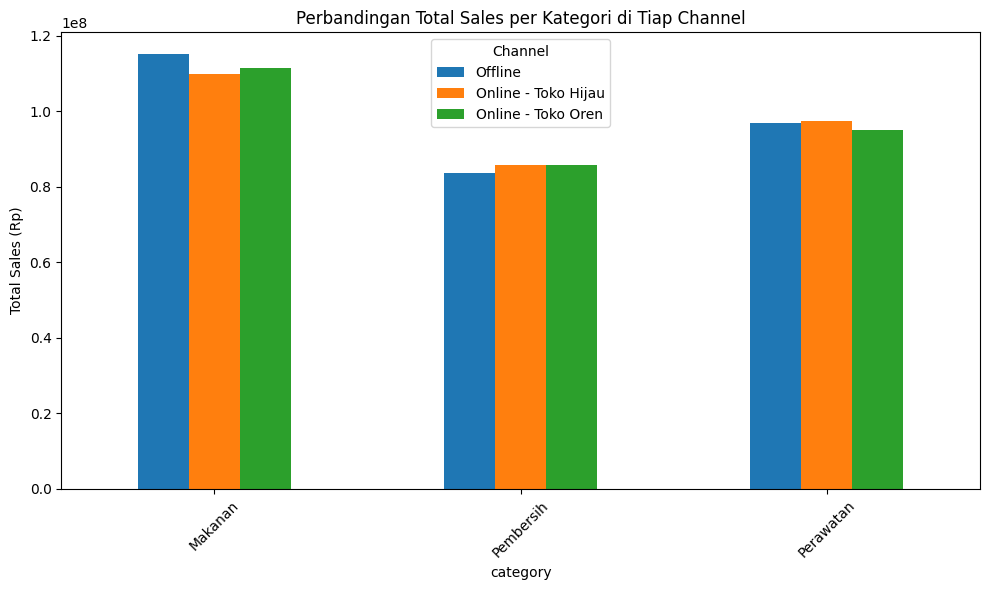


--- Top 5 Produk Terlaris ---


channel,Offline,Online - Toko Hijau,Online - Toko Oren,Total
product_name,,,,
Kopi,"Rp 46,264,993","Rp 43,033,995","Rp 45,669,993","Rp 134,968,980"
Shampo,"Rp 37,157,994","Rp 36,152,993","Rp 37,097,993","Rp 110,408,979"
Minyak Goreng,"Rp 36,586,992","Rp 36,003,995","Rp 35,106,995","Rp 107,697,982"
Pasta Gigi,"Rp 31,261,994","Rp 33,549,993","Rp 32,782,992","Rp 97,594,979"
Teh,"Rp 32,279,994","Rp 30,721,994","Rp 30,570,993","Rp 93,572,982"


In [28]:
import matplotlib.pyplot as plt

# 1. Analisis Kategori per Channel dengan Format Rupiah
summary_category = df_channel.pivot_table(
    index='category', 
    columns='channel', 
    values='total_sales', 
    aggfunc='sum', 
    fill_value=0
)
summary_category['Total'] = summary_category.sum(axis=1)

# Menampilkan tabel dengan format Rupiah
print("--- Performa Kategori per Channel ---")
display(summary_category.style.format("Rp {:,.0f}"))

# Visualisasi 
summary_category.drop(columns='Total').plot(kind='bar', figsize=(10, 6))
plt.title('Perbandingan Total Sales per Kategori di Tiap Channel')
plt.ylabel('Total Sales (Rp)')
plt.xticks(rotation=45)
plt.legend(title='Channel')
plt.tight_layout()
plt.show()


# 2. Analisis Top 5 Produk Terlaris
summary_product = df_channel.pivot_table(
    index='product_name', 
    columns='channel', 
    values='total_sales', 
    aggfunc='sum', 
    fill_value=0
)
summary_product['Total'] = summary_product.sum(axis=1)

# Menampilkan Top 5 produk
top_5_products = summary_product.sort_values(by='Total', ascending=False).head(5)
print("\n--- Top 5 Produk Terlaris ---")
display(top_5_products.style.format("Rp {:,.0f}"))